# 02 — Chest X-ray Baseline Model (DenseNet121)

**Academic prototype only.** This notebook trains a reproducible multi-label
baseline for a university final project. It is **not** a clinical diagnostic
system and must **never** be used for patient care.

## Scope

- Train / validate only on the **patient-safe** clean splits from notebook 01:
  `data/processed/xray/train_clean.csv` and `valid_clean.csv`.
- Images come from `data/raw/xray/nih/images-small/` (read-only).
- The official `test.csv` is **not** used in this notebook.

## Design choices (why this baseline)

| Choice | Reason |
|---|---|
| **DenseNet121 + ImageNet weights** | Transfer learning gives strong visual features with few labelled X-rays; DenseNet is a standard chest X-ray baseline (e.g. CheXNet-style setups). |
| **Sigmoid, 14 outputs** | Each disease is an independent binary label (multi-label). Softmax would force mutually exclusive classes. |
| **Weighted binary cross-entropy** | Positives are rare (especially Hernia). Weights from **train only** rebalance the loss. |
| **Patient-safe validation** | `train_clean` / `valid_clean` have zero shared `PatientId`, so validation is not leaked. |
| **No official test yet** | Test is reserved for final, once-only evaluation after the baseline is fixed. |

## 0. Setup, seeds, and paths

In [1]:
from pathlib import Path
import os
import random
import time

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

IMAGE_SIZE = 320
BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 1e-3
DROPOUT = 0.3

RAW_IMAGE_DIR = PROJECT_ROOT / "data" / "raw" / "xray" / "nih" / "images-small"
TRAIN_CSV = PROJECT_ROOT / "data" / "processed" / "xray" / "train_clean.csv"
VALID_CSV = PROJECT_ROOT / "data" / "processed" / "xray" / "valid_clean.csv"

FIG_PATH = PROJECT_ROOT / "outputs" / "figures" / "xray" / "baseline_training_curves.png"
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics" / "xray" / "baseline_valid_auroc.csv"
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "xray" / "xray_densenet121_baseline.keras"

LABEL_COLS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
    "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass", "Nodule",
    "Pleural_Thickening", "Pneumonia", "Pneumothorax",
]

print("Project root:", PROJECT_ROOT)
print(f"BATCH_SIZE={BATCH_SIZE}  IMAGE_SIZE={IMAGE_SIZE}  EPOCHS={EPOCHS}  SEED={SEED}")

Project root: D:\AI Engineering\medicaldiagnostic_finalproject
BATCH_SIZE=8  IMAGE_SIZE=320  EPOCHS=3  SEED=42


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

np.random.seed(SEED)

try:
    import tensorflow as tf
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing required package: tensorflow. "
        "Install it in this project's .venv, then re-run the notebook."
    ) from exc

tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPU devices:", gpus if gpus else "None detected (CPU)")
print("pandas:", pd.__version__, "| numpy:", np.__version__)

TensorFlow: 2.19.1
GPU devices: None detected (CPU)
pandas: 3.0.5 | numpy: 2.1.3


## 1. Load clean splits and run pre-training checks

We only use `train_clean.csv` and `valid_clean.csv`. Raw CSVs and the official
test set are left untouched.

In [3]:
def load_clean_csv(path: Path, name: str) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Missing {name}: {path}")
    df = pd.read_csv(path)
    required = ["Image", "PatientId"] + LABEL_COLS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")
    return df[required].copy()


train_df = load_clean_csv(TRAIN_CSV, "train_clean.csv")
valid_df = load_clean_csv(VALID_CSV, "valid_clean.csv")

print(f"train_clean: {len(train_df)} rows, {train_df['PatientId'].nunique()} patients")
print(f"valid_clean: {len(valid_df)} rows, {valid_df['PatientId'].nunique()} patients")
print("[ok] All 14 disease-label columns present in both CSVs")

train_clean: 948 rows, 744 patients
valid_clean: 252 rows, 186 patients
[ok] All 14 disease-label columns present in both CSVs


In [4]:
available_images = {
    p.name
    for p in RAW_IMAGE_DIR.iterdir()
    if p.is_file()
    and p.suffix.lower() == ".png"
    and not p.name.startswith("._")
    and p.name != ".DS_Store"
}
print(f"Available PNGs in images-small/: {len(available_images)}")


def assert_images_exist(df: pd.DataFrame, name: str) -> None:
    missing = sorted(set(df["Image"]) - available_images)
    if missing:
        raise FileNotFoundError(
            f"{name}: {len(missing)} image(s) missing. Examples: {missing[:5]}"
        )
    print(f"[ok] {name}: all {len(df)} referenced images exist")


assert_images_exist(train_df, "train_clean")
assert_images_exist(valid_df, "valid_clean")

overlap = set(train_df["PatientId"]) & set(valid_df["PatientId"])
print(f"PatientId overlap train ∩ valid: {len(overlap)}")
if overlap:
    raise RuntimeError(f"Patient leakage detected ({len(overlap)} shared PatientIds). Stop.")
print("[ok] No PatientId overlap between train_clean and valid_clean")

train_pos = train_df[LABEL_COLS].sum().astype(int)
zero_pos = [c for c in LABEL_COLS if train_pos[c] == 0]
print("\nTraining positive counts:")
display(train_pos.to_frame("positives").T)

if zero_pos:
    raise RuntimeError(
        "Cannot train: these labels have ZERO positives in train_clean.csv: "
        f"{zero_pos}. Refusing to invent class weights or drop classes."
    )
print("[ok] Every disease label has ≥1 positive in training data")

Available PNGs in images-small/: 1422
[ok] train_clean: all 948 referenced images exist
[ok] valid_clean: all 252 referenced images exist
PatientId overlap train ∩ valid: 0
[ok] No PatientId overlap between train_clean and valid_clean

Training positive counts:


,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
positives,102,17,36,10,132,15,8,2,165,44,58,22,9,33


[ok] Every disease label has ≥1 positive in training data


## 2. Class-imbalance weights (train_clean only)

For each disease label $j$ let $N$ be the number of training images,
$P_j$ the number of positives, and $N_j = N - P_j$ the negatives.

$$
w^{+}_j = \frac{N_j}{P_j}, \qquad w^{-}_j = \frac{P_j}{N_j}
$$

Weighted binary cross-entropy for label $j$:

$$
\mathcal{L}_j = -\big( w^{+}_j\, y_j \log p_j + w^{-}_j\, (1-y_j)\log(1-p_j) \big)
$$

Weights are computed **only** from `train_clean.csv` — never from validation or test.

In [5]:
y_train = train_df[LABEL_COLS].to_numpy(dtype=np.float32)
y_valid = valid_df[LABEL_COLS].to_numpy(dtype=np.float32)

N = len(train_df)
pos = y_train.sum(axis=0)
neg = N - pos
w_pos = (neg / pos).astype(np.float32)
w_neg = (pos / neg).astype(np.float32)

weight_table = pd.DataFrame({
    "positives": pos.astype(int),
    "negatives": neg.astype(int),
    "w_pos": w_pos,
    "w_neg": w_neg,
}, index=LABEL_COLS)
display(weight_table.round(3))

W_POS = tf.constant(w_pos, dtype=tf.float32)
W_NEG = tf.constant(w_neg, dtype=tf.float32)
EPS = 1e-7


def weighted_binary_crossentropy(y_true, y_pred):
    """Multi-label weighted BCE using train-derived w_pos / w_neg."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, EPS, 1.0 - EPS)
    loss = -(W_POS * y_true * tf.math.log(y_pred) + W_NEG * (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    # mean over labels, then over batch
    return tf.reduce_mean(tf.reduce_mean(loss, axis=-1))


print("[ok] Class weights ready (from train_clean only)")

,positives,negatives,w_pos,w_neg
Atelectasis,102,846,8.294000,0.121
Cardiomegaly,17,931,54.764999,0.018
Consolidation,36,912,25.333000,0.039
Edema,10,938,93.800003,0.011
Effusion,132,816,6.182000,0.162
Emphysema,15,933,62.200001,0.016
Fibrosis,8,940,117.500000,0.009
Hernia,2,946,473.000000,0.002
Infiltration,165,783,4.745000,0.211
Mass,44,904,20.545000,0.049


[ok] Class weights ready (from train_clean only)


## 3. `tf.data` input pipeline

- Decode original grayscale PNGs as **3 channels** (RGB replication).
- Resize to **320×320**.
- Apply **only** `tf.keras.applications.densenet.preprocess_input`.
- Do **not** divide by 255 or add any other normalisation.

In [6]:
preprocess_input = tf.keras.applications.densenet.preprocess_input


def make_dataset(df: pd.DataFrame, *, shuffle: bool, batch_size: int) -> tf.data.Dataset:
    paths = [str(RAW_IMAGE_DIR / name) for name in df["Image"].tolist()]
    labels = df[LABEL_COLS].to_numpy(dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    def _load(path, label):
        image_bytes = tf.io.read_file(path)
        # channels=3: grayscale PNGs are expanded to 3 identical channels
        image = tf.io.decode_png(image_bytes, channels=3)
        image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
        image = tf.cast(image, tf.float32)
        image = preprocess_input(image)  # DenseNet only — no /255
        return image, label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True, batch_size=BATCH_SIZE)
valid_ds = make_dataset(valid_df, shuffle=False, batch_size=BATCH_SIZE)

xb, yb = next(iter(train_ds))
print("Batch images:", xb.shape, xb.dtype)
print("Batch labels:", yb.shape, yb.dtype)
print(f"Value range after DenseNet preprocess: [{float(tf.reduce_min(xb)):.1f}, {float(tf.reduce_max(xb)):.1f}]")

Batch images: (8, 320, 320, 3) <dtype: 'float32'>
Batch labels: (8, 14) <dtype: 'float32'>
Value range after DenseNet preprocess: [-2.1, 2.6]


## 4. Build DenseNet121 baseline

- Backbone: `DenseNet121(include_top=False)`, ImageNet weights, **frozen** for this baseline.
- Head: GlobalAveragePooling2D → Dropout(0.3) → Dense(14, sigmoid).
- Optimiser: Adam (`1e-3`).

If ImageNet weights cannot be downloaded, this cell stops with the exact error
(no silent fallback to random weights or course `.h5` files).

In [7]:
try:
    backbone = tf.keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    )
except Exception as exc:
    raise RuntimeError(
        "Failed to load DenseNet121 with ImageNet pretrained weights. "
        "Stopping as required (no random-weight or course-weight fallback).\n"
        f"Exact error: {type(exc).__name__}: {exc}"
    ) from exc

backbone.trainable = False  # freeze for this baseline

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = backbone(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
outputs = tf.keras.layers.Dense(len(LABEL_COLS), activation="sigmoid", name="disease_probs")(x)

model = tf.keras.Model(inputs, outputs, name="xray_densenet121_baseline")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=weighted_binary_crossentropy,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy", threshold=0.5),
    ],
)

model.summary()
trainable = sum(int(np.prod(v.shape)) for v in model.trainable_weights)
frozen = sum(int(np.prod(v.shape)) for v in model.non_trainable_weights)
print(f"Trainable params: {trainable:,} | Non-trainable (frozen) params: {frozen:,}")

       0/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/29084464 ━━━━━━━━━━━━━━━━━━━━ 3:24 7us/step

   40960/29084464 ━━━━━━━━━━━━━━━━━━━━ 2:02 4us/step

   49152/29084464 ━━━━━━━━━━━━━━━━━━━━ 2:42 6us/step

   81920/29084464 ━━━━━━━━━━━━━━━━━━━━ 2:33 5us/step

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 10, 10, 1024)   │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ disease_probs (Dense)           │ (None, 14)             │        14,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,051,854 (26.90 MB)

 Trainable params: 14,350 (56.05 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Trainable params: 14,350 | Non-trainable (frozen) params: 7,037,504


## 5. Train (validation = valid_clean only)

EarlyStopping monitors `val_loss` and restores the best weights.

> **Note on binary accuracy:** with rare positives, predicting “absent” for most
> labels looks accurate. Prefer **AUROC** on validation for this imbalanced
> multi-label problem. We do **not** tune decision thresholds here.

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

t0 = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1,
)
train_seconds = time.perf_counter() - t0

hist = pd.DataFrame(history.history)
hist.insert(0, "epoch", np.arange(1, len(hist) + 1))
display(hist)

best_epoch = int(np.argmin(hist["val_loss"].to_numpy()) + 1)
best_val_loss = float(hist["val_loss"].min())
print(f"Training time: {train_seconds/60:.2f} min ({train_seconds:.1f} s)")
print(f"Best val_loss: {best_val_loss:.4f} (epoch {best_epoch})")

Epoch 1/3


D:\AI Engineering\medicaldiagnostic_finalproject\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/119 ━━━━━━━━━━━━━━━━━━━━ 20:33 10s/step - binary_accuracy: 0.4018 - loss: 0.4981

  2/119 ━━━━━━━━━━━━━━━━━━━━ 33s 283ms/step - binary_accuracy: 0.4688 - loss: 0.5725

  3/119 ━━━━━━━━━━━━━━━━━━━━ 33s 285ms/step - binary_accuracy: 0.5089 - loss: 0.4819

...

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - binary_accuracy: 0.0599 - loss: 0.1889

119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 348ms/step - binary_accuracy: 0.0599 - loss: 0.1889 - val_binary_accuracy: 0.0445 - val_loss: 0.1707


Restoring model weights from the end of the best epoch: 3.


,epoch,binary_accuracy,loss,val_binary_accuracy,val_loss
0,1,0.279762,0.805906,0.113946,0.415944
1,2,0.095690,0.299425,0.045918,0.191180
2,3,0.059901,0.188853,0.044501,0.170710


Training time: 2.30 min (137.9 s)
Best val_loss: 0.1707 (epoch 3)


## 6. Validation AUROC (no threshold tuning)

Per-disease AUROC is reported only when `valid_clean` contains **both** a
positive and a negative example for that label. Macro AUROC is the mean of
those defined per-class scores.

In [9]:
y_prob = model.predict(valid_ds, verbose=0)
y_true = y_valid

rows = []
defined_aucs = []
for i, disease in enumerate(LABEL_COLS):
    yt = y_true[:, i]
    yp = y_prob[:, i]
    n_pos = int(yt.sum())
    n_neg = int(len(yt) - n_pos)
    if n_pos == 0 or n_neg == 0:
        auc = np.nan
        note = "undefined (need both classes in validation)"
    else:
        auc = float(roc_auc_score(yt, yp))
        defined_aucs.append(auc)
        note = "ok"
    rows.append({
        "disease": disease,
        "valid_positives": n_pos,
        "valid_negatives": n_neg,
        "auroc": auc,
        "note": note,
    })

auroc_df = pd.DataFrame(rows)
macro_auroc = float(np.mean(defined_aucs)) if defined_aucs else float("nan")

display(auroc_df)
print(f"Macro AUROC over {len(defined_aucs)} defined classes: {macro_auroc:.4f}")
print(
    "Reminder: binary accuracy is misleading under class imbalance; "
    "AUROC is the primary validation metric here. Thresholds are not tuned yet."
)

,disease,valid_positives,valid_negatives,auroc,note
0,Atelectasis,23,229,0.593317,ok
1,Cardiomegaly,7,245,0.419825,ok
2,Consolidation,4,248,0.238911,ok
3,Edema,8,244,0.319928,ok
4,Effusion,23,229,0.723372,ok
5,Emphysema,1,251,0.992032,ok
6,Fibrosis,7,245,0.831487,ok
7,Hernia,1,251,0.988048,ok
8,Infiltration,39,213,0.537258,ok
9,Mass,10,242,0.418595,ok


Macro AUROC over 14 defined classes: 0.5800
Reminder: binary accuracy is misleading under class imbalance; AUROC is the primary validation metric here. Thresholds are not tuned yet.


## 7. Save training curves, metrics, and best model

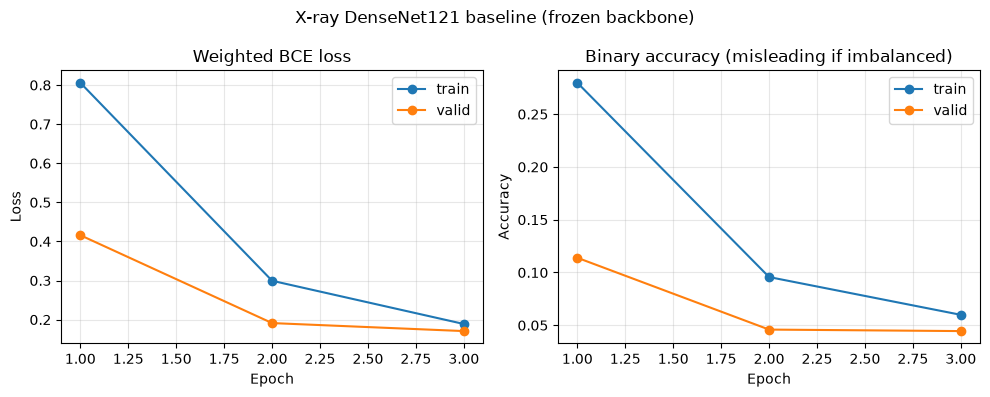

Saved figure: outputs\figures\xray\baseline_training_curves.png
Saved metrics: outputs\metrics\xray\baseline_valid_auroc.csv


Saved model  : outputs\models\xray\xray_densenet121_baseline.keras


In [10]:
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
epochs_axis = hist["epoch"]

axes[0].plot(epochs_axis, hist["loss"], marker="o", label="train")
axes[0].plot(epochs_axis, hist["val_loss"], marker="o", label="valid")
axes[0].set_title("Weighted BCE loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_axis, hist["binary_accuracy"], marker="o", label="train")
axes[1].plot(epochs_axis, hist["val_binary_accuracy"], marker="o", label="valid")
axes[1].set_title("Binary accuracy (misleading if imbalanced)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("X-ray DenseNet121 baseline (frozen backbone)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", FIG_PATH.relative_to(PROJECT_ROOT))

auroc_save = auroc_df.copy()
auroc_save.loc[len(auroc_save)] = {
    "disease": "MACRO",
    "valid_positives": np.nan,
    "valid_negatives": np.nan,
    "auroc": macro_auroc,
    "note": f"mean of {len(defined_aucs)} defined per-class AUROCs",
}
auroc_save.to_csv(METRICS_PATH, index=False)
print("Saved metrics:", METRICS_PATH.relative_to(PROJECT_ROOT))

model.save(MODEL_PATH)
print("Saved model  :", MODEL_PATH.relative_to(PROJECT_ROOT))

## 8. Summary

- DenseNet121 transfer learning with a **frozen** ImageNet backbone and a small
  sigmoid head is a standard, reproducible academic baseline for 14-label CXR.
- **Sigmoid** outputs treat diseases as independent labels (multi-label).
- **Weighted BCE** (weights from `train_clean` only) counters severe imbalance.
- Validation uses the **patient-safe** `valid_clean` split only.
- The official **test set remains untouched** until final evaluation.

In [11]:
print("=== Baseline run summary ===")
print("TensorFlow :", tf.__version__)
print("GPU        :", gpus if gpus else "None (CPU)")
print("Epochs run :", len(hist))
print("Train time :", f"{train_seconds:.1f}s")
print("Best val_loss:", f"{best_val_loss:.4f}", f"(epoch {best_epoch})")
print("Macro AUROC:", f"{macro_auroc:.4f}")
print("Outputs:")
print(" -", FIG_PATH.relative_to(PROJECT_ROOT))
print(" -", METRICS_PATH.relative_to(PROJECT_ROOT))
print(" -", MODEL_PATH.relative_to(PROJECT_ROOT))

=== Baseline run summary ===
TensorFlow : 2.19.1
GPU        : None (CPU)
Epochs run : 3
Train time : 137.9s
Best val_loss: 0.1707 (epoch 3)
Macro AUROC: 0.5800
Outputs:
 - outputs\figures\xray\baseline_training_curves.png
 - outputs\metrics\xray\baseline_valid_auroc.csv
 - outputs\models\xray\xray_densenet121_baseline.keras
